In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# загрузка данных
df = pd.read_csv('../data/retention_full.csv', sep=';')

df.head()

,acquisition_channel,days_since_registration,retention
0,ads,0,21.6
1,ads,1,23.2
2,ads,2,25.6
3,ads,3,21.6
4,ads,4,28.0


In [3]:
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16549 entries, 0 to 16548
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   acquisition_channel      16549 non-null  object 
 1   days_since_registration  16549 non-null  int64  
 2   retention                16549 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 388.0+ KB
None
  acquisition_channel  days_since_registration  retention
0                 ads                        0       21.6
1                 ads                        1       23.2
2                 ads                        2       25.6
3                 ads                        3       21.6
4                 ads                        4       28.0


In [11]:
# Проверяем, отличаются ли retention между каналами ads и referral
# Нулевая гипотеза (H0): различий нет
# Альтернативная гипотеза (H1): различия есть

In [4]:
# дни для анализа
days = [1, 3, 7, 14, 30]
alpha = 0.05

results = []

for day in days:
    subset = df[df['days_since_registration'] == day]
    
    ads = subset[subset['acquisition_channel'] == 'ads']['retention']
    referral = subset[subset['acquisition_channel'] == 'referral']['retention']
    
    print(f"Day {day}")
    print("ads count:", len(ads))
    print("referral count:", len(referral))
    
    # обработка случая с малым количеством данных
    if len(ads) < 2 or len(referral) < 2:
        print(" → недостаточно данных для статистического теста\n")
        continue
    
    stat, p_value = ttest_ind(ads, referral)
    
    print(f"p-value = {p_value}")
    
    if p_value < alpha:
        print(" → различие статистически значимо\n")
        significant = True
    else:
        print(" → различие незначимо\n")
        significant = False
    
    results.append({
        'day': day,
        'p_value': p_value,
        'significant': significant
    })

Day 1
ads count: 180
referral count: 180
p-value = 6.10073170906395e-32
 → различие статистически значимо

Day 3
ads count: 180
referral count: 180
p-value = 4.828673291805427e-21
 → различие статистически значимо

Day 7
ads count: 180
referral count: 180
p-value = 1.2880591328378034e-139
 → различие статистически значимо

Day 14
ads count: 180
referral count: 180
p-value = 9.812576191256212e-183
 → различие статистически значимо

Day 30
ads count: 0
referral count: 180
 → недостаточно данных для статистического теста



In [5]:
# итоговая таблица
results_df = pd.DataFrame(results)
print(results_df)

   day        p_value  significant
0    1   6.100732e-32         True
1    3   4.828673e-21         True
2    7  1.288059e-139         True
3   14  9.812576e-183         True


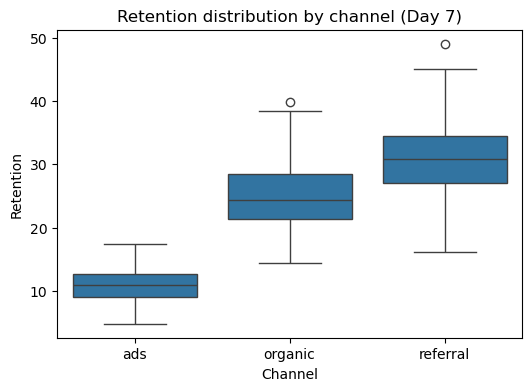

In [6]:
# берем ключевой день (например, 7)
day7 = df[df['days_since_registration'] == 7]

plt.figure(figsize=(6, 4))
sns.boxplot(data=day7, x='acquisition_channel', y='retention')

plt.title("Retention distribution by channel (Day 7)")
plt.xlabel("Channel")
plt.ylabel("Retention")

plt.show()


In [7]:
print("\nВывод:")

if not results_df.empty and results_df['significant'].all():
    print("Во все дни различия между каналами статистически значимы.")
else:
    print("Часть дней не имеет значимых различий или недостаточно данных.")

print("Канал ads стабильно показывает более низкий retention по сравнению с referral.")
print("Различие не является случайным.")


Вывод:
Во все дни различия между каналами статистически значимы.
Канал ads стабильно показывает более низкий retention по сравнению с referral.
Различие не является случайным.
